https://archive.ics.uci.edu/dataset/320/student+performance


This project is to determine, using numerous factors, which of the two portuguese schools the student goes to. There are 25+ factors in the data.
For example:
- Internet: depending on how much many students have internet access can determine what school they go to
- G3: Having higher or lower grades can determine what school
- Location: Whether they live in rural or urban can determine what school

ETC.

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
student_performance = fetch_ucirepo(id=320)

# data (as pandas dataframes)
X = student_performance.data.features
y = student_performance.data.targets





In [ ]:
y.head()

,G1,G2,G3
0,0,11,11
1,9,11,11
2,12,13,12
3,14,14,14
4,11,13,13


In [ ]:
student_performance.variables

,name,role,type,demographic,description,units,missing_values
0,school,Feature,Categorical,None,student's school (binary: 'GP' - Gabriel Perei...,None,no
1,sex,Feature,Binary,Sex,student's sex (binary: 'F' - female or 'M' - m...,None,no
2,age,Feature,Integer,Age,student's age (numeric: from 15 to 22),None,no
3,address,Feature,Categorical,None,student's home address type (binary: 'U' - urb...,None,no
4,famsize,Feature,Categorical,Other,family size (binary: 'LE3' - less or equal to ...,None,no
5,Pstatus,Feature,Categorical,Other,parent's cohabitation status (binary: 'T' - li...,None,no
6,Medu,Feature,Integer,Education Level,"mother's education (numeric: 0 - none, 1 - pr...",None,no
7,Fedu,Feature,Integer,Education Level,"father's education (numeric: 0 - none, 1 - pr...",None,no
8,Mjob,Feature,Categorical,Occupation,"mother's job (nominal: 'teacher', 'health' car...",None,no
9,Fjob,Feature,Categorical,Occupation,"father's job (nominal: 'teacher', 'health' car...",None,no


In [ ]:
# prompt: make X variable have all varibales except absences

X = student_performance.data.features.drop(columns=['absences'])

In [ ]:
import pandas as pd
data = pd.concat([X, y], axis=1)
data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,romantic,famrel,freetime,goout,Dalc,Walc,health,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,4,3,4,1,1,3,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,no,5,3,3,1,1,3,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,no,4,3,2,2,3,3,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,3,2,2,1,1,5,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,4,3,2,1,2,5,11,13,13


In [ ]:
data['school'].value_counts()

,count
school,
GP,423
MS,226


In [ ]:
X = data.drop(['school','romantic','nursery','health','G1','G2'],axis=1)
y = data['school']

In [ ]:
X

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,paid,activities,higher,internet,famrel,freetime,goout,Dalc,Walc,G3
0,F,18,U,GT3,A,4,4,at_home,teacher,course,...,no,no,yes,no,4,3,4,1,1,11
1,F,17,U,GT3,T,1,1,at_home,other,course,...,no,no,yes,yes,5,3,3,1,1,11
2,F,15,U,LE3,T,1,1,at_home,other,other,...,no,no,yes,yes,4,3,2,2,3,12
3,F,15,U,GT3,T,4,2,health,services,home,...,no,yes,yes,yes,3,2,2,1,1,14
4,F,16,U,GT3,T,3,3,other,other,home,...,no,no,yes,no,4,3,2,1,2,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,F,19,R,GT3,T,2,3,services,other,course,...,no,yes,yes,yes,5,4,2,1,2,10
645,F,18,U,LE3,T,3,1,teacher,services,course,...,no,no,yes,yes,4,3,4,1,1,16
646,F,18,U,GT3,T,1,1,other,other,course,...,no,yes,yes,no,1,1,1,1,1,9
647,M,17,U,LE3,T,3,1,services,services,course,...,no,no,yes,yes,2,4,5,3,4,10


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 26 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   sex         649 non-null    object
 1   age         649 non-null    int64 
 2   address     649 non-null    object
 3   famsize     649 non-null    object
 4   Pstatus     649 non-null    object
 5   Medu        649 non-null    int64 
 6   Fedu        649 non-null    int64 
 7   Mjob        649 non-null    object
 8   Fjob        649 non-null    object
 9   reason      649 non-null    object
 10  guardian    649 non-null    object
 11  traveltime  649 non-null    int64 
 12  studytime   649 non-null    int64 
 13  failures    649 non-null    int64 
 14  schoolsup   649 non-null    object
 15  famsup      649 non-null    object
 16  paid        649 non-null    object
 17  activities  649 non-null    object
 18  higher      649 non-null    object
 19  internet    649 non-null    object
 20  famrel    

In [ ]:
numerical = X.select_dtypes(include=['int64','float64'])
categorical = X.select_dtypes(include=['object'])

In [ ]:
categorical.head()

,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,higher,internet
0,F,U,GT3,A,at_home,teacher,course,mother,yes,no,no,no,yes,no
1,F,U,GT3,T,at_home,other,course,father,no,yes,no,no,yes,yes
2,F,U,LE3,T,at_home,other,other,mother,yes,no,no,no,yes,yes
3,F,U,GT3,T,health,services,home,mother,no,yes,no,yes,yes,yes
4,F,U,GT3,T,other,other,home,father,no,yes,no,no,yes,no


In [ ]:
cat_numerical = pd.get_dummies(categorical, drop_first=True)
cat_numerical.head()


,sex_M,address_U,famsize_LE3,Pstatus_T,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,Fjob_other,...,reason_other,reason_reputation,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,higher_yes,internet_yes
0,False,True,False,False,False,False,False,False,False,False,...,False,False,True,False,True,False,False,False,True,False
1,False,True,False,True,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,True,True
2,False,True,True,True,False,False,False,False,False,True,...,True,False,True,False,True,False,False,False,True,True
3,False,True,False,True,True,False,False,False,False,False,...,False,False,True,False,False,True,False,True,True,True
4,False,True,False,True,False,True,False,False,False,True,...,False,False,False,False,False,True,False,False,True,False


In [ ]:
X = pd.concat([numerical, cat_numerical], axis = 1)
X.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,reason_other,reason_reputation,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,higher_yes,internet_yes
0,18,4,4,2,2,0,4,3,4,1,...,False,False,True,False,True,False,False,False,True,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,False,False,True,False,False,True,True
2,15,1,1,1,2,0,4,3,2,2,...,True,False,True,False,True,False,False,False,True,True
3,15,4,2,1,3,0,3,2,2,1,...,False,False,True,False,False,True,False,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,False,False,True,False,False,True,False


In [ ]:
y = pd.get_dummies(y,drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)


In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform (X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
log_clf = LogisticRegression()
classifier = log_clf.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test,y_pred))


[[71 15]
 [15 29]]
              precision    recall  f1-score   support

       False       0.83      0.83      0.83        86
        True       0.66      0.66      0.66        44

    accuracy                           0.77       130
   macro avg       0.74      0.74      0.74       130
weighted avg       0.77      0.77      0.77       130



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

knn_clf = KNeighborsClassifier(n_neighbors=10)
classifier = knn_clf.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


[[82  4]
 [31 13]]
              precision    recall  f1-score   support

       False       0.73      0.95      0.82        86
        True       0.76      0.30      0.43        44

    accuracy                           0.73       130
   macro avg       0.75      0.62      0.63       130
weighted avg       0.74      0.73      0.69       130

Accuracy: 0.7307692307692307


/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [ ]:
from sklearn import svm

svm_clf = svm.SVC()
classifier = svm_clf.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[[76 10]
 [19 25]]
              precision    recall  f1-score   support

       False       0.80      0.88      0.84        86
        True       0.71      0.57      0.63        44

    accuracy                           0.78       130
   macro avg       0.76      0.73      0.74       130
weighted avg       0.77      0.78      0.77       130

Accuracy: 0.7769230769230769


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=10, n_estimators=9)
classifier = rf_clf.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


[[78  8]
 [19 25]]
              precision    recall  f1-score   support

       False       0.80      0.91      0.85        86
        True       0.76      0.57      0.65        44

    accuracy                           0.79       130
   macro avg       0.78      0.74      0.75       130
weighted avg       0.79      0.79      0.78       130

Accuracy: 0.7923076923076923


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Classifier had best accuracy so cross val will be done with that model. Had to test with different n_estimators and found 9 gives the highest.

In [ ]:
from sklearn.model_selection import cross_val_score

print(cross_val_score(classifier, X, y.squeeze(), cv=5, scoring="accuracy"))

[0.80769231 0.75384615 0.67692308 0.67692308 0.68217054]


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_pred_prob = rf_clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob, pos_label=1)
roc_auc = roc_auc_score(y_test, y_pred_prob)
roc_auc

0.7936046511627908

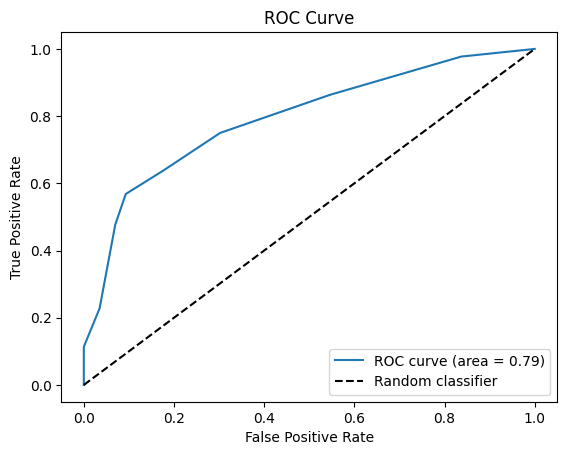

In [ ]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()


In conclusion, there is a 79 percent chance we can predict which of the two schools a student goes to using the decision. The ROC_AUC curve is also displayed and shows a decent accuracy with the blue line close to the top left corner

--
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-
-